# 2026 World Cup Upset Predictions
Uses the trained ELO engine + XGBoost classifier to predict upset probabilities
for every 2026 World Cup group stage fixture.

**Run `upset_classifier.ipynb` first** — this notebook reuses the `xgb` model and `engine` from that session,
or you can re-fit them in the setup cell below.

## 1. Setup — fit engine & model

In [14]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import shap

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import sys, os
sys.path.insert(0, os.getcwd())
from elo_engine import (
    EloEngine, get_k_factor, confederation_k_multiplier,
    get_confederation, expected_score, normalize_name
)

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})
print('Imports OK')

Imports OK


In [15]:
# Fit ELO engine on full dataset
results_df = pd.read_csv('results.csv')
print(f"Dataset runs to: {results_df['date'].max()}")

engine = EloEngine()
engine.fit(results_df)
print('ELO engine ready.')

Dataset runs to: 2026-06-27
Dropped 72 rows with missing scores.
Replayed 49,365 matches. 333 unique teams rated.
Mean reversion applied at 22 WC cycles: [1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
ELO engine ready.


In [16]:
# Re-train XGBoost on the full feature matrix
FEATURE_COLS = [
    'elo_diff', 'form_elo_diff', 'conf_k_mult', 'same_conf',
    'is_neutral', 'tournament_k', 'pre_prob_home',
]
TARGET_COL = 'target'

df = pd.read_csv('classifier_features.csv', parse_dates=['date'])

# Train on everything before the 2026 WC (June 11 2026)
train = df[df['date'] < '2026-06-11'].dropna(subset=FEATURE_COLS)
X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='logloss', random_state=42, verbosity=0,
)
xgb.fit(X_train, y_train, verbose=False)
print(f'XGBoost trained on {len(X_train):,} matches  ({y_train.mean():.1%} upsets)')

XGBoost trained on 49,365 matches  (19.9% upsets)


## 2. Step 2 — Real form ELO for every 2026 team
Computes each team's ELO using only their last 3 years of matches (2023–2026).
This is the value we use for `form_elo_diff` in predictions instead of the all-time proxy.

In [17]:
from collections import defaultdict
from datetime import datetime, timedelta

def compute_form_elo(team: str, results_df: pd.DataFrame,
                     reference_date: str = '2026-06-11',
                     window_days: int = 365 * 3) -> float:
    """
    Replay only the last `window_days` of matches up to `reference_date`
    and return the team's ELO from that window.
    """
    team = normalize_name(team)
    ref  = pd.Timestamp(reference_date)
    start = ref - pd.Timedelta(days=window_days)

    df = results_df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['home_team'] = df['home_team'].map(normalize_name)
    df['away_team'] = df['away_team'].map(normalize_name)
    df = df.dropna(subset=['home_score','away_score'])

    window = df[(df['date'] >= start) & (df['date'] < ref)]
    window = window.sort_values('date')

    mini = defaultdict(lambda: 1500.0)
    for _, row in window.iterrows():
        rh = mini[row['home_team']]
        ra = mini[row['away_team']]
        hs, as_ = int(row['home_score']), int(row['away_score'])
        sc = 1.0 if hs > as_ else (0.0 if hs < as_ else 0.5)
        k  = get_k_factor(str(row.get('tournament',''))) * \
             confederation_k_multiplier(row['home_team'], row['away_team'])
        exp = 1.0 / (1.0 + 10 ** ((ra - rh) / 400))
        gd  = abs(hs - as_)
        import numpy as _np
        mult = 1.0 if gd <= 1 else _np.log(gd + 1) * 1.5
        delta = k * mult * (sc - exp)
        mini[row['home_team']] = rh + delta
        mini[row['away_team']] = ra - delta

    return mini[team]


# Compute form ELO for all 48 qualified teams
WC2026_TEAMS = [
    # Group A
    'Mexico', 'Czech Republic', 'South Africa', 'South Korea',
    # Group B
    'Switzerland', 'Canada', 'Bosnia and Herzegovina', 'Qatar',
    # Group C
    'Brazil', 'Morocco', 'Scotland', 'Haiti',
    # Group D
    'Turkey', 'United States', 'Paraguay', 'Australia',
    # Group E
    'Germany', 'Ivory Coast', 'Ecuador', 'Curaçao',
    # Group F
    'Netherlands', 'Japan', 'Sweden', 'Tunisia',
    # Group G
    'Belgium', 'Egypt', 'Iran', 'New Zealand',
    # Group H
    'Spain', 'Uruguay', 'Saudi Arabia', 'Cape Verde',
    # Group I
    'France', 'Senegal', 'Norway', 'Iraq',
    # Group J
    'Argentina', 'Austria', 'Algeria', 'Jordan',
    # Group K
    'Portugal', 'Colombia', 'DR Congo', 'Uzbekistan',
    # Group L
    'England', 'Croatia', 'Ghana', 'Panama',
]

WC2026_TEAMS = list(dict.fromkeys(WC2026_TEAMS))

print('Computing form ELO for all qualified teams...')
form_elos = {}
for team in WC2026_TEAMS:
    form_elos[team] = compute_form_elo(team, results_df)

form_df = pd.DataFrame([
    {'team': t, 'all_time_elo': round(engine.rating(t), 1),
     'form_elo': round(form_elos[t], 1),
     'confederation': get_confederation(t) or 'unknown'}
    for t in WC2026_TEAMS
]).sort_values('all_time_elo', ascending=False).reset_index(drop=True)

form_df['elo_diff'] = (form_df['form_elo'] - form_df['all_time_elo']).round(1)
form_df['trend'] = form_df['elo_diff'].apply(
    lambda x: '▲ in form' if x > 20 else ('▼ fading' if x < -20 else '→ stable')
)

print(form_df[['team','all_time_elo','form_elo','elo_diff','trend']].to_string(index=False))

Computing form ELO for all qualified teams...
                  team  all_time_elo  form_elo  elo_diff    trend
                 Spain        2080.4    1830.2    -250.2 ▼ fading
             Argentina        2031.6    1700.2    -331.4 ▼ fading
                France        2019.7    1718.2    -301.5 ▼ fading
               England        1995.4    1773.2    -222.2 ▼ fading
              Portugal        1935.1    1700.8    -234.3 ▼ fading
               Morocco        1920.8    1841.3     -79.5 ▼ fading
                 Japan        1914.4    1753.6    -160.8 ▼ fading
                Brazil        1913.8    1590.7    -323.1 ▼ fading
           Netherlands        1905.5    1680.8    -224.7 ▼ fading
              Colombia        1898.3    1639.5    -258.8 ▼ fading
               Germany        1881.2    1695.9    -185.3 ▼ fading
                Mexico        1877.1    1699.6    -177.5 ▼ fading
               Croatia        1873.8    1659.1    -214.7 ▼ fading
             Australia        

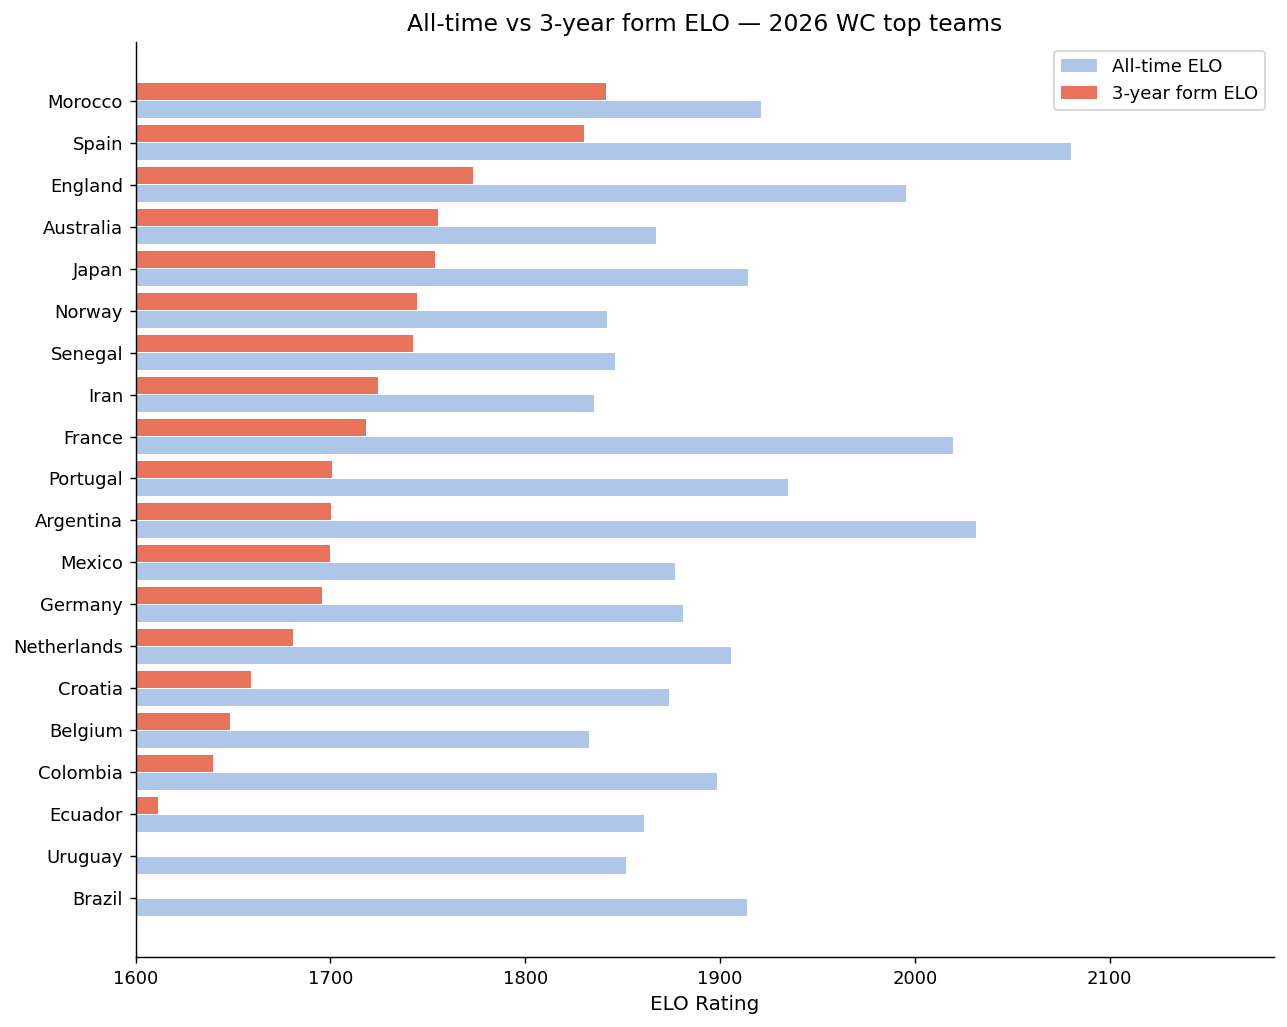

In [18]:
# Visualise: all-time vs form ELO for top 20 teams
top20 = form_df.head(20).sort_values('form_elo')

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(top20))

ax.barh(y, top20['all_time_elo'], color='#AEC6E8', label='All-time ELO', height=0.4, align='center')
ax.barh([i + 0.42 for i in y], top20['form_elo'], color='#E8735A',
        label='3-year form ELO', height=0.4, align='center')

ax.set_yticks([i + 0.21 for i in y])
ax.set_yticklabels(top20['team'], fontsize=10)
ax.set_xlabel('ELO Rating', fontsize=11)
ax.set_title('All-time vs 3-year form ELO — 2026 WC top teams', fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(1600)
plt.tight_layout()
plt.savefig('form_vs_alltime.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Step 1 & 3 — Predict every group stage fixture

In [19]:
# 2026 World Cup group stage fixtures
# Format: (home, away, group)
# All group stage matches are at neutral venues
FIXTURES = [
    # Group A
    ('Mexico',              'Czech Republic',       'A'),
    ('South Africa',        'South Korea',          'A'),
    ('Mexico',              'South Africa',         'A'),
    ('Czech Republic',      'South Korea',          'A'),
    ('Czech Republic',      'South Africa',         'A'),
    ('Mexico',              'South Korea',          'A'),
    # Group B
    ('Switzerland',         'Canada',               'B'),
    ('Bosnia and Herzegovina', 'Qatar',             'B'),
    ('Switzerland',         'Bosnia and Herzegovina','B'),
    ('Canada',              'Qatar',                'B'),
    ('Canada',              'Bosnia and Herzegovina','B'),
    ('Switzerland',         'Qatar',                'B'),
    # Group C
    ('Brazil',              'Morocco',              'C'),
    ('Scotland',            'Haiti',                'C'),
    ('Brazil',              'Scotland',             'C'),
    ('Morocco',             'Haiti',                'C'),
    ('Morocco',             'Scotland',             'C'),
    ('Brazil',              'Haiti',                'C'),
    # Group D
    ('Turkey',              'United States',        'D'),
    ('Paraguay',            'Australia',            'D'),
    ('Turkey',              'Paraguay',             'D'),
    ('United States',       'Australia',            'D'),
    ('United States',       'Paraguay',             'D'),
    ('Turkey',              'Australia',            'D'),
    # Group E
    ('Germany',             'Ivory Coast',          'E'),
    ('Ecuador',             'Curacao',              'E'),
    ('Germany',             'Ecuador',              'E'),
    ('Ivory Coast',         'Curacao',              'E'),
    ('Ivory Coast',         'Ecuador',              'E'),
    ('Germany',             'Curacao',              'E'),
    # Group F
    ('Netherlands',         'Japan',                'F'),
    ('Sweden',              'Tunisia',              'F'),
    ('Netherlands',         'Sweden',               'F'),
    ('Japan',               'Tunisia',              'F'),
    ('Japan',               'Sweden',               'F'),
    ('Netherlands',         'Tunisia',              'F'),
    # Group G
    ('Belgium',             'Egypt',                'G'),
    ('Iran',                'New Zealand',          'G'),
    ('Belgium',             'Iran',                 'G'),
    ('Egypt',               'New Zealand',          'G'),
    ('Egypt',               'Iran',                 'G'),
    ('Belgium',             'New Zealand',          'G'),
    # Group H
    ('Spain',               'Uruguay',              'H'),
    ('Saudi Arabia',        'Cape Verde',           'H'),
    ('Spain',               'Saudi Arabia',         'H'),
    ('Uruguay',             'Cape Verde',           'H'),
    ('Uruguay',             'Saudi Arabia',         'H'),
    ('Spain',               'Cape Verde',           'H'),
    # Group I
    ('France',              'Senegal',              'I'),
    ('Norway',              'Iraq',                 'I'),
    ('France',              'Norway',               'I'),
    ('Senegal',             'Iraq',                 'I'),
    ('Senegal',             'Norway',               'I'),
    ('France',              'Iraq',                 'I'),
    # Group J
    ('Argentina',           'Austria',              'J'),
    ('Algeria',             'Jordan',               'J'),
    ('Argentina',           'Algeria',              'J'),
    ('Austria',             'Jordan',               'J'),
    ('Austria',             'Algeria',              'J'),
    ('Argentina',           'Jordan',               'J'),
    # Group K
    ('Portugal',            'Colombia',             'K'),
    ('DR Congo',            'Uzbekistan',           'K'),
    ('Portugal',            'DR Congo',             'K'),
    ('Colombia',            'Uzbekistan',           'K'),
    ('Colombia',            'DR Congo',             'K'),
    ('Portugal',            'Uzbekistan',           'K'),
    # Group L
    ('England',             'Croatia',              'L'),
    ('Ghana',               'Panama',               'L'),
    ('England',             'Ghana',                'L'),
    ('Croatia',             'Panama',               'L'),
    ('Croatia',             'Ghana',                'L'),
    ('England',             'Panama',               'L'),
]

print(f'Total group stage fixtures: {len(FIXTURES)}')

Total group stage fixtures: 72


In [20]:
def predict_fixture(home, away, group, neutral=True, tournament='FIFA World Cup'):
    """Returns a dict with full prediction for one fixture."""
    r_home = engine.rating(home)
    r_away = engine.rating(away)
    r_home_eff = r_home + (0 if neutral else 100)

    p_home    = expected_score(r_home_eff, r_away)
    conf_mult = confederation_k_multiplier(home, away)
    same_conf = int(
        get_confederation(home) == get_confederation(away)
        and get_confederation(home) is not None
    )
    t_k = get_k_factor(tournament) * conf_mult

    # Use real form ELO if available, else fall back to all-time
    f_home = form_elos.get(home, r_home)
    f_away = form_elos.get(away, r_away)

    features = pd.DataFrame([{
        'elo_diff':      r_home - r_away,
        'form_elo_diff': f_home - f_away,
        'conf_k_mult':   conf_mult,
        'same_conf':     same_conf,
        'is_neutral':    int(neutral),
        'tournament_k':  t_k,
        'pre_prob_home': p_home,
    }])

    upset_prob = xgb.predict_proba(features)[0][1]
    favorite   = home if p_home >= 0.5 else away
    underdog   = away if p_home >= 0.5 else home

    return {
        'group':       group,
        'home':        home,
        'away':        away,
        'elo_home':    round(r_home, 1),
        'elo_away':    round(r_away, 1),
        'form_home':   round(f_home, 1),
        'form_away':   round(f_away, 1),
        'p_home':      round(p_home * 100, 1),
        'p_away':      round((1 - p_home) * 100, 1),
        'favorite':    favorite,
        'underdog':    underdog,
        'upset_prob':  round(upset_prob * 100, 1),
    }


# Run all fixtures
predictions = pd.DataFrame([predict_fixture(*f) for f in FIXTURES])
print(f'Predictions generated for {len(predictions)} fixtures.')
predictions.head(6)

Predictions generated for 72 fixtures.


,group,home,away,elo_home,elo_away,form_home,form_away,p_home,p_away,favorite,underdog,upset_prob
0,A,Mexico,Czech Republic,1877.1,1678.5,1699.6,1578.1,75.8,24.2,Mexico,Czech Republic,29.900000
1,A,South Africa,South Korea,1639.6,1828.7,1620.9,1676.9,25.2,74.8,South Korea,South Africa,41.400002
2,A,Mexico,South Africa,1877.1,1639.6,1699.6,1620.9,79.7,20.3,Mexico,South Africa,26.900000
3,A,Czech Republic,South Korea,1678.5,1828.7,1578.1,1676.9,29.6,70.4,South Korea,Czech Republic,50.000000
4,A,Czech Republic,South Africa,1678.5,1639.6,1578.1,1620.9,55.6,44.4,Czech Republic,South Africa,55.599998
5,A,Mexico,South Korea,1877.1,1828.7,1699.6,1676.9,56.9,43.1,Mexico,South Korea,52.400002


In [21]:
# Full ranked table — most likely upsets first
ranked = predictions.sort_values('upset_prob', ascending=False).reset_index(drop=True)
ranked.index += 1

display_cols = ['group', 'home', 'away', 'p_home', 'p_away', 'upset_prob', 'underdog']
print('=== All group stage fixtures ranked by upset probability ===')
print(ranked[display_cols].to_string())

=== All group stage fixtures ranked by upset probability ===
   group                    home                    away  p_home  p_away  upset_prob                underdog
1      J                 Austria                  Jordan    48.4    51.6   70.599998                 Austria
2      B             Switzerland                  Canada    49.5    50.5   70.300003             Switzerland
3      G                 Belgium                    Iran    49.7    50.3   70.199997                 Belgium
4      B  Bosnia and Herzegovina                   Qatar    47.3    52.7   70.000000  Bosnia and Herzegovina
5      F             Netherlands                   Japan    48.7    51.3   69.699997             Netherlands
6      C                 Morocco                Scotland    74.1    25.9   66.900002                Scotland
7      D                  Turkey                Paraguay    59.3    40.7   66.000000                Paraguay
8      C                  Brazil                 Morocco    49.0   

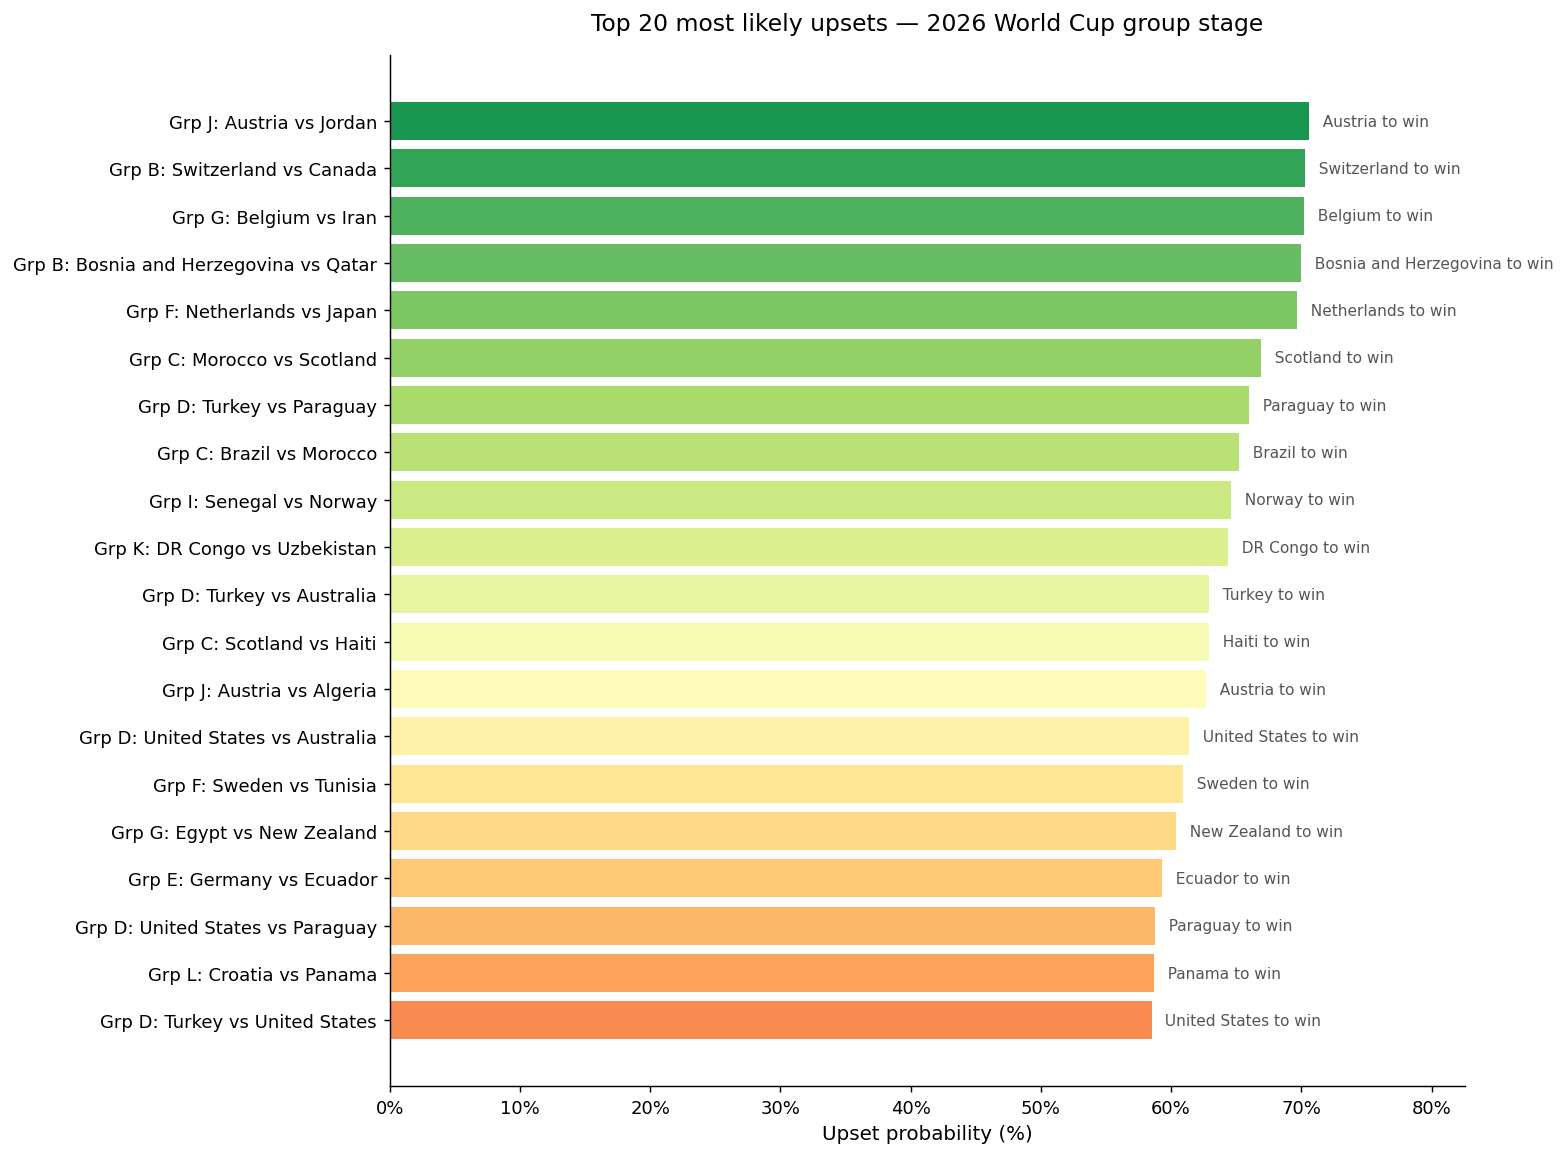

In [22]:
# Top 20 most dangerous upsets — the matches to watch
top20 = ranked.head(20)

labels = top20.apply(
    lambda r: f"Grp {r['group']}: {r['home']} vs {r['away']}", axis=1
)

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.75, len(top20)))

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(labels[::-1], top20['upset_prob'][::-1], color=colors[::-1])

# Annotate with underdog name
for bar, (_, row) in zip(bars, top20[::-1].iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"  {row['underdog']} to win",
            va='center', fontsize=8.5, color='#555')

ax.set_xlabel('Upset probability (%)', fontsize=11)
ax.set_title('Top 20 most likely upsets — 2026 World Cup group stage', fontsize=13, pad=14)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, top20['upset_prob'].max() + 12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('wc2026_top_upsets.png', dpi=150, bbox_inches='tight')
plt.show()

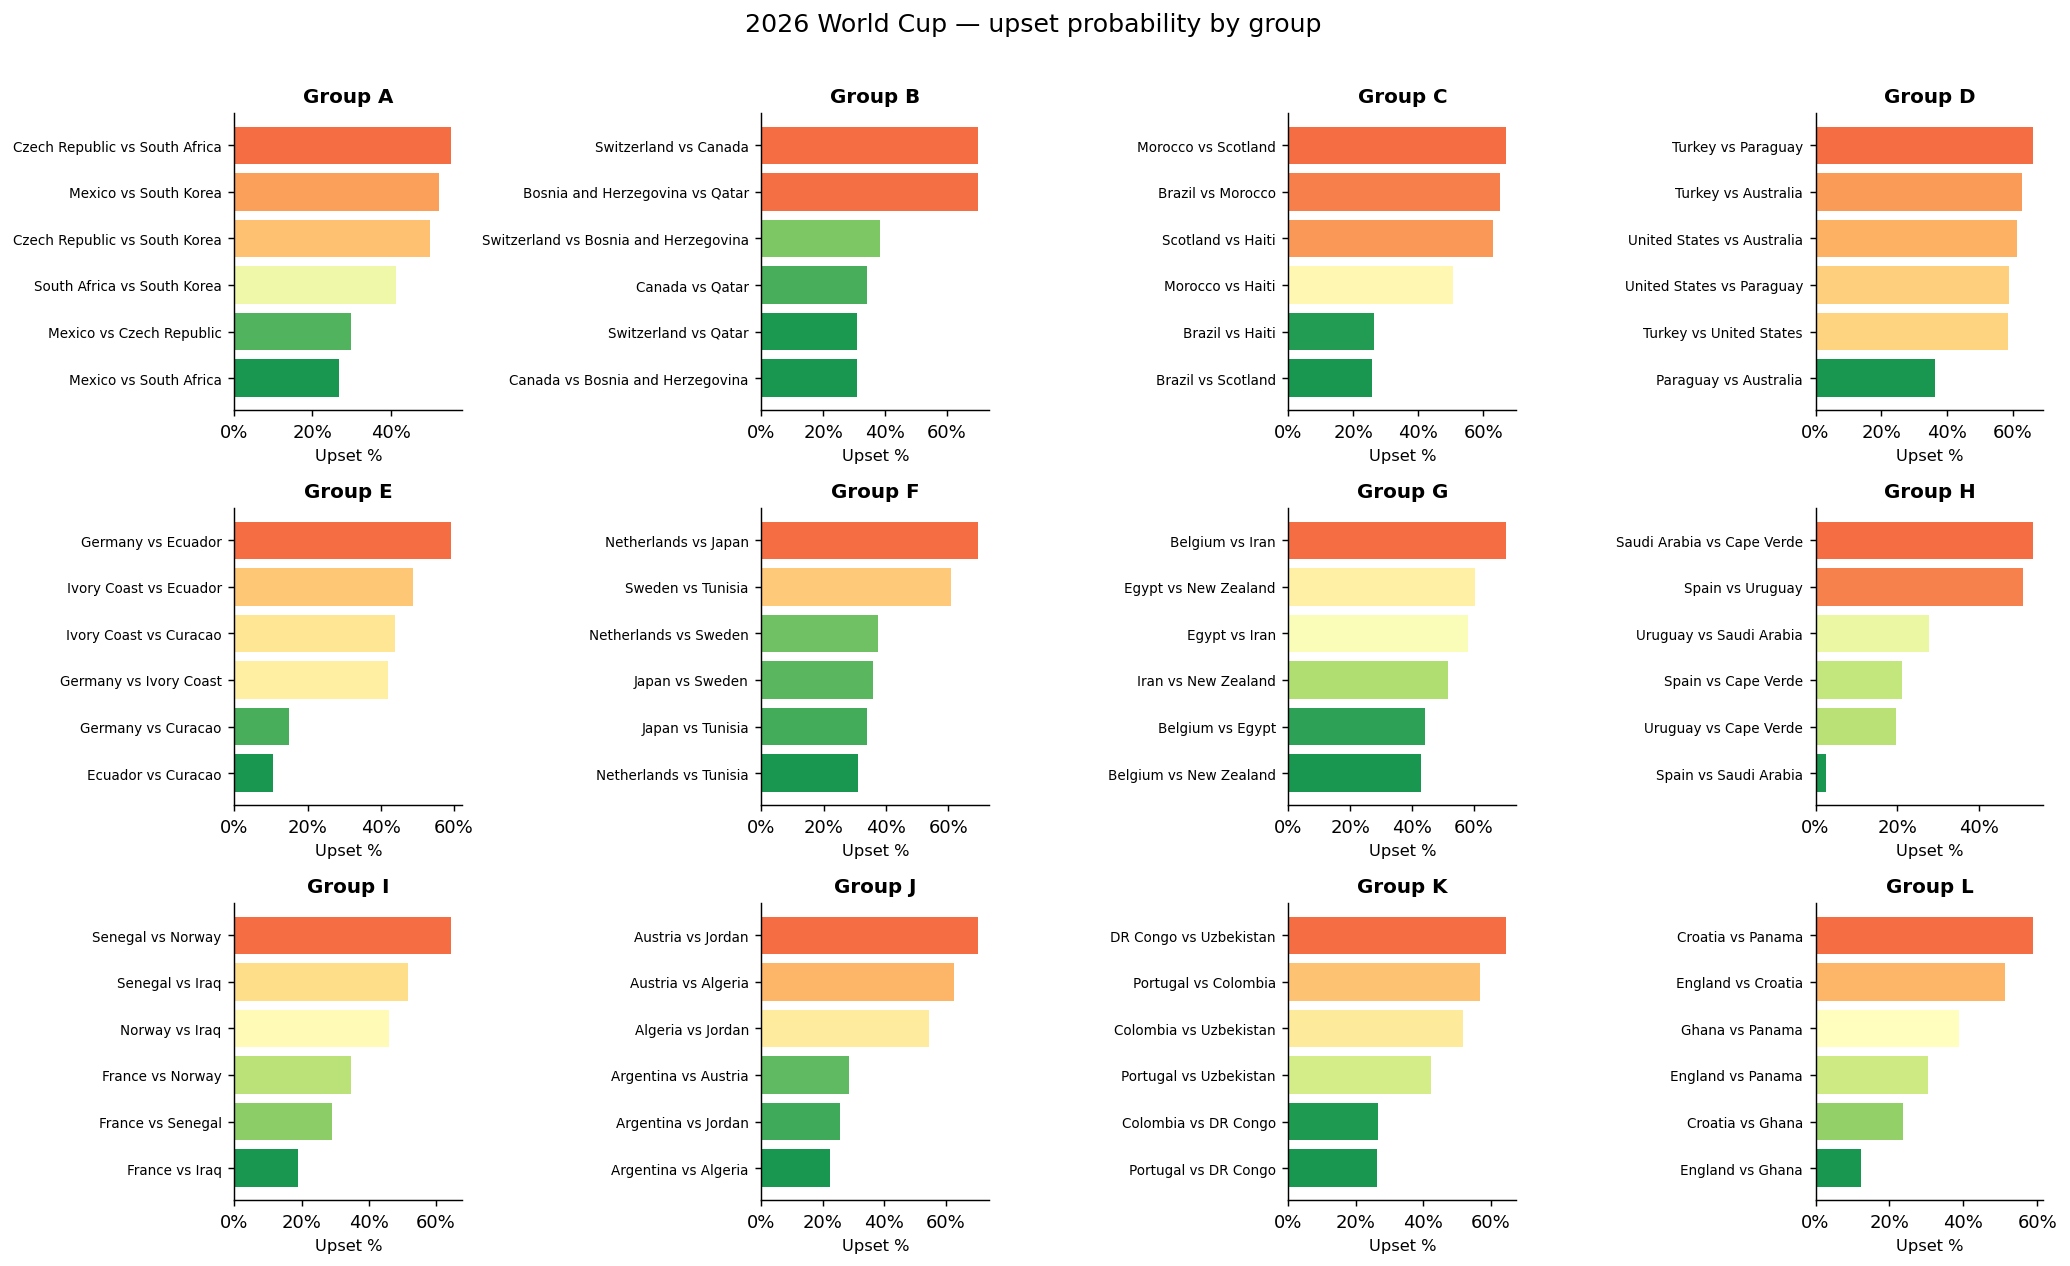

In [23]:
# Group-by-group heatmap of upset risk
# Shows every match in each group coloured by upset probability

groups = sorted(predictions['group'].unique())
n_groups = len(groups)
cols = 4
rows = (n_groups + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.2))
axes = axes.flatten()

for idx, grp in enumerate(groups):
    ax = axes[idx]
    grp_df = predictions[predictions['group'] == grp].copy()
    grp_df['matchup'] = grp_df['home'] + ' vs ' + grp_df['away']
    grp_df = grp_df.sort_values('upset_prob', ascending=True)

    bar_colors = plt.cm.RdYlGn_r(
        (grp_df['upset_prob'] - grp_df['upset_prob'].min()) /
        max(grp_df['upset_prob'].max() - grp_df['upset_prob'].min(), 1) * 0.7 + 0.1
    )
    ax.barh(grp_df['matchup'], grp_df['upset_prob'], color=bar_colors)
    ax.set_title(f'Group {grp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Upset %', fontsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=7.5)

# Hide unused subplots
for idx in range(n_groups, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('2026 World Cup — upset probability by group', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('wc2026_groups_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Group advancement simulation
10,000 Monte Carlo runs per group — who is most likely to advance?

In [24]:
from collections import defaultdict

WC2026_GROUPS = {
    'A': ['Mexico', 'Czech Republic', 'South Africa', 'South Korea'],
    'B': ['Switzerland', 'Canada', 'Bosnia and Herzegovina', 'Qatar'],
    'C': ['Brazil', 'Morocco', 'Scotland', 'Haiti'],
    'D': ['Turkey', 'United States', 'Paraguay', 'Australia'],
    'E': ['Germany', 'Ivory Coast', 'Ecuador', 'Curacao'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Uruguay', 'Saudi Arabia', 'Cape Verde'],
    'I': ['France', 'Senegal', 'Norway', 'Iraq'],
    'J': ['Argentina', 'Austria', 'Algeria', 'Jordan'],
    'K': ['Portugal', 'Colombia', 'DR Congo', 'Uzbekistan'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama'],
}

N_SIMS = 10_000

def simulate_group(teams, engine, n_sims=10_000):
    matchups = [(teams[i], teams[j]) for i in range(4) for j in range(i+1, 4)]
    advance  = defaultdict(int)

    for _ in range(n_sims):
        pts = defaultdict(int)
        gd  = defaultdict(int)

        for a, b in matchups:
            ra = engine.rating(a)
            rb = engine.rating(b)
            p_a = 1.0 / (1.0 + 10 ** ((rb - ra) / 400))
            r   = np.random.random()

            draw_prob = 0.25 * (1 - abs(p_a - 0.5) * 2)
            if r < draw_prob:
                pts[a] += 1; pts[b] += 1
            elif r < draw_prob + p_a * (1 - draw_prob):
                pts[a] += 3; gd[a] += 1; gd[b] -= 1
            else:
                pts[b] += 3; gd[b] += 1; gd[a] -= 1

        ranked = sorted(teams, key=lambda t: (pts[t], gd[t]), reverse=True)
        advance[ranked[0]] += 1
        advance[ranked[1]] += 1

    return pd.DataFrame([
        {'team': t, 'advance_%': round(advance[t] / n_sims * 100, 1)}
        for t in teams
    ]).sort_values('advance_%', ascending=False).reset_index(drop=True)


print(f'Simulating all 12 groups ({N_SIMS:,} runs each)...')
group_sims = {grp: simulate_group(teams, engine, N_SIMS)
              for grp, teams in WC2026_GROUPS.items()}

for grp, sim in group_sims.items():
    print(f"\nGroup {grp}:")
    print(sim.to_string(index=False))

Simulating all 12 groups (10,000 runs each)...

Group A:
          team  advance_%
        Mexico       82.1
   South Korea       60.5
Czech Republic       35.2
  South Africa       22.3

Group B:
                  team  advance_%
           Switzerland       84.4
                Canada       83.1
                 Qatar       16.3
Bosnia and Herzegovina       16.2

Group C:
    team  advance_%
  Brazil       77.3
 Morocco       76.2
Scotland       25.1
   Haiti       21.4

Group D:
         team  advance_%
       Turkey       60.5
    Australia       56.7
United States       47.9
     Paraguay       34.9

Group E:
       team  advance_%
    Germany       82.3
    Ecuador       65.4
Ivory Coast       47.1
    Curacao        5.2

Group F:
       team  advance_%
Netherlands       80.5
      Japan       79.3
    Tunisia       25.2
     Sweden       14.9

Group G:
       team  advance_%
    Belgium       70.9
       Iran       61.6
      Egypt       41.3
New Zealand       26.1

Group H:
   

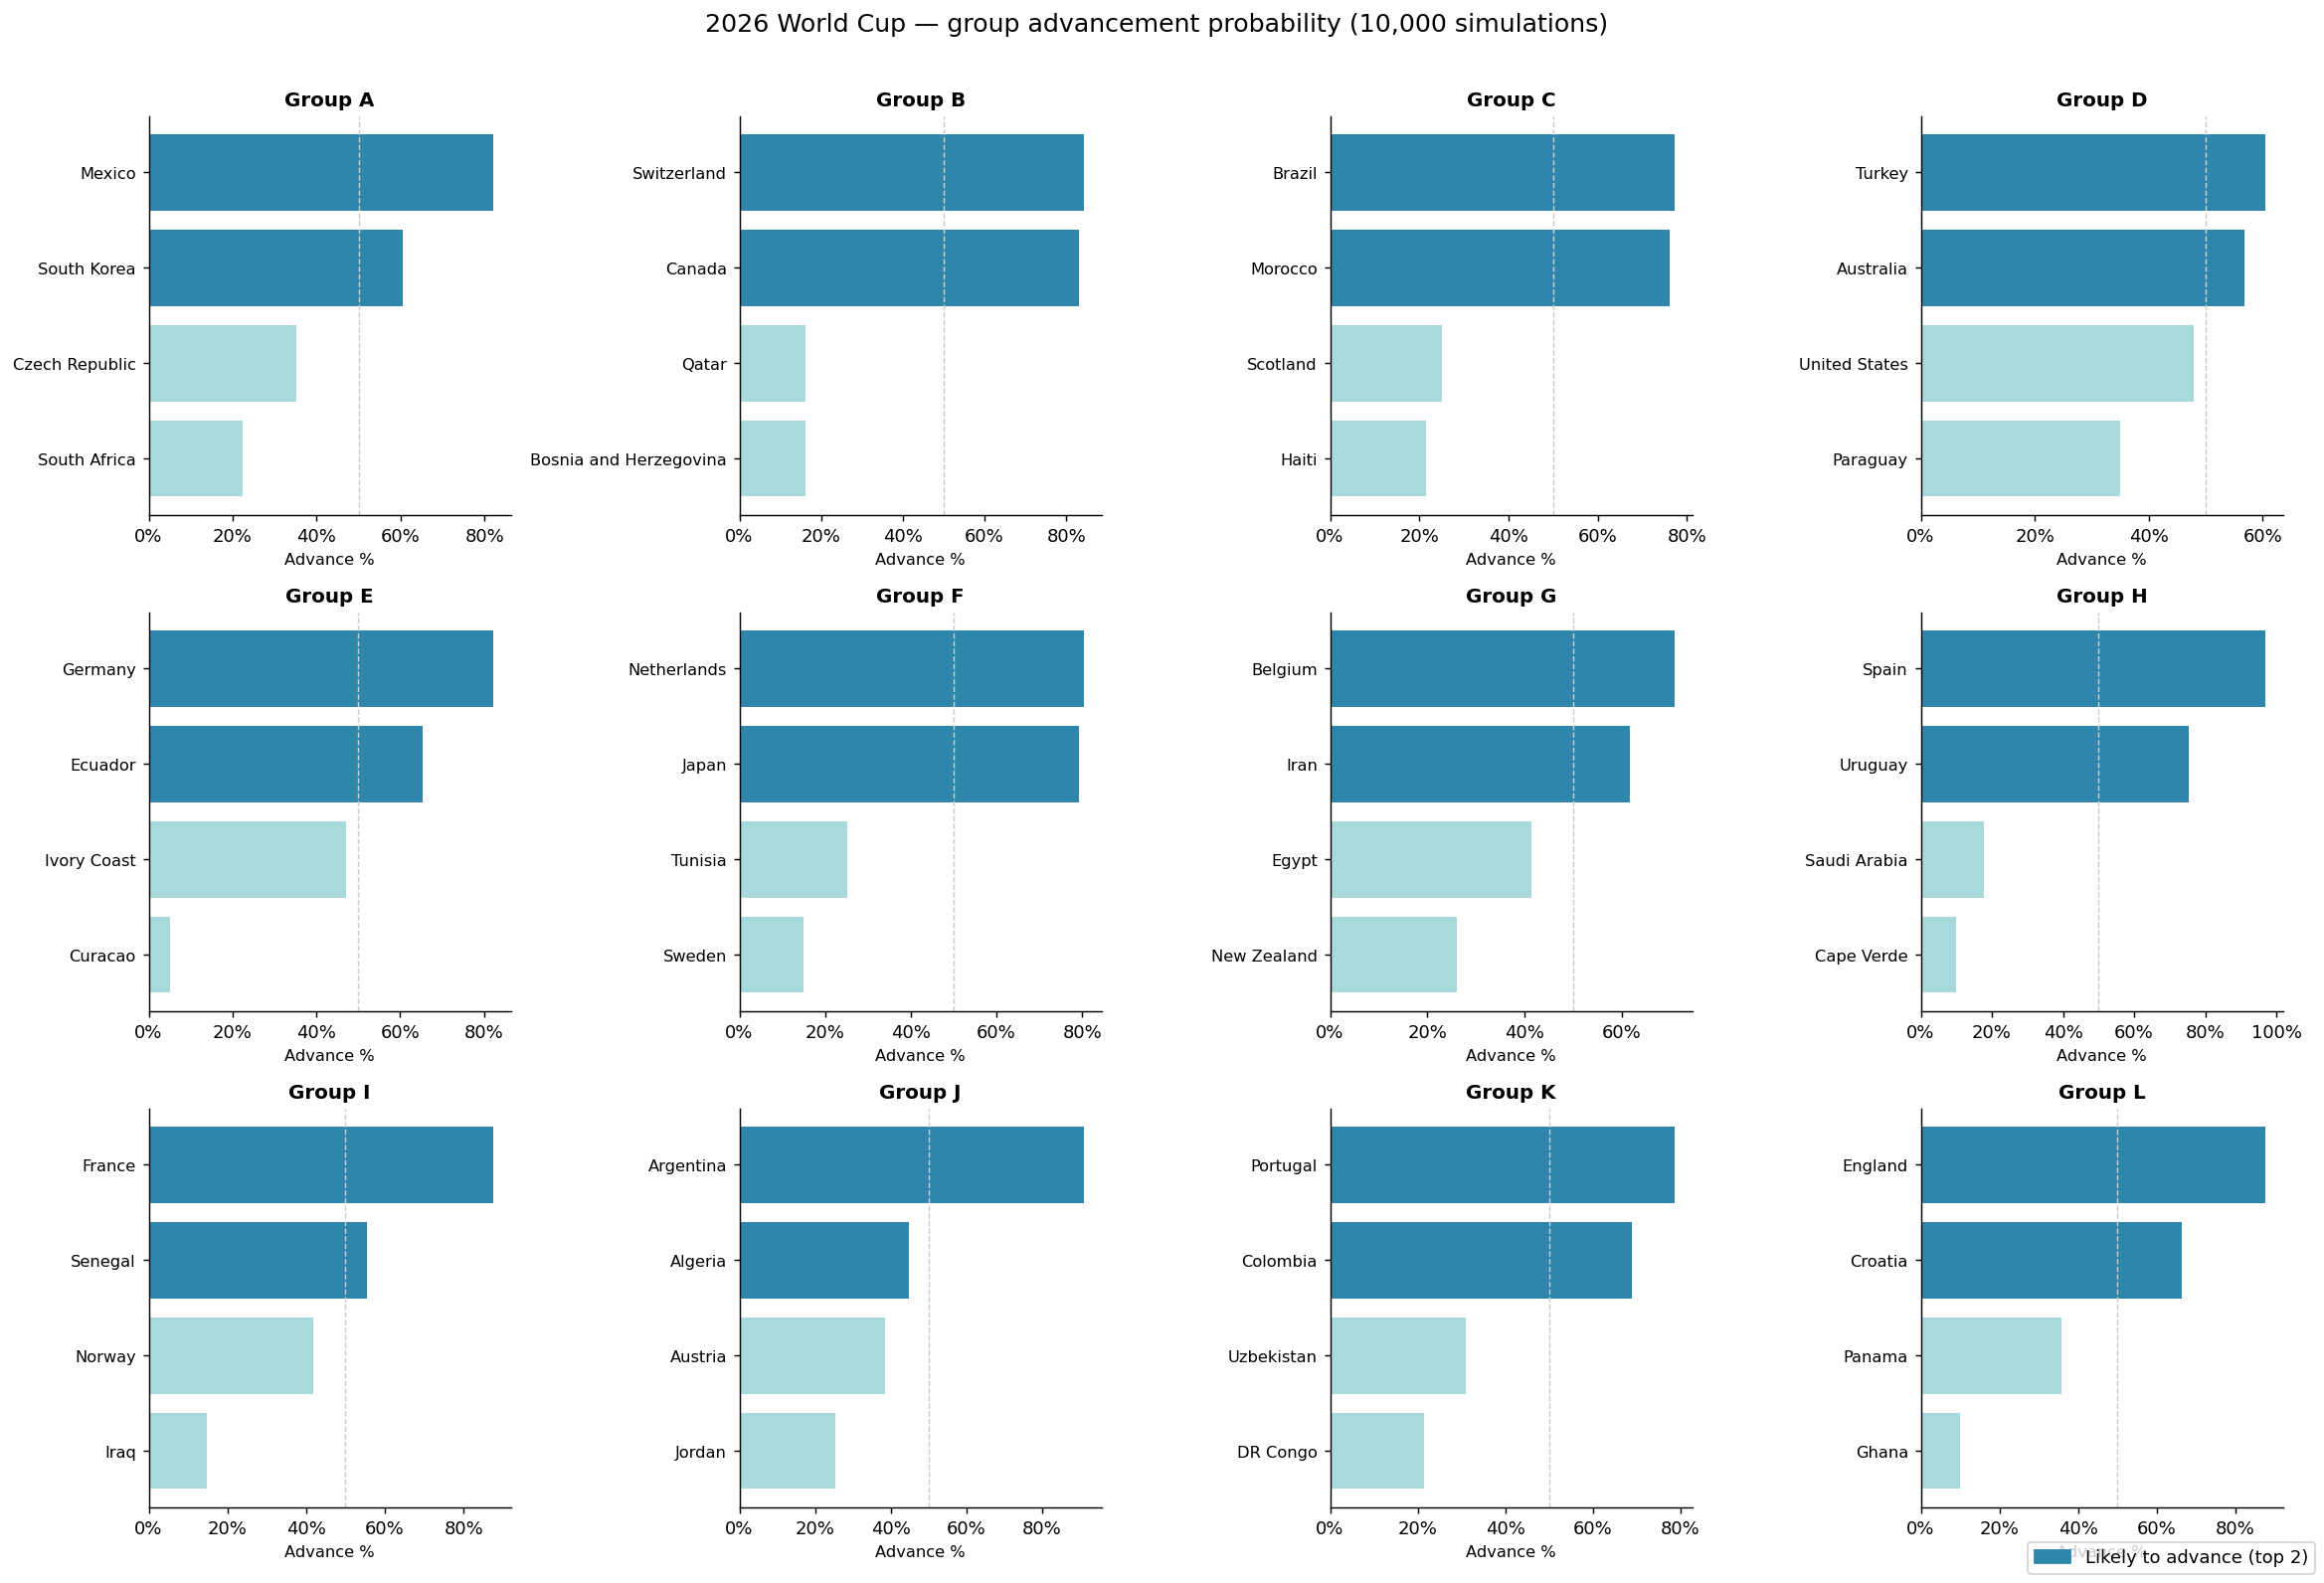

In [25]:
# Visualise all group simulations
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, (grp, sim) in enumerate(group_sims.items()):
    ax = axes[idx]
    colors = ['#2E86AB' if i < 2 else '#A8DADC' for i in range(len(sim))]
    ax.barh(sim['team'][::-1], sim['advance_%'][::-1], color=colors[::-1])
    ax.set_title(f'Group {grp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Advance %', fontsize=9)
    ax.axvline(50, color='#ccc', linestyle='--', linewidth=0.8)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)

advance_patch = mpatches.Patch(color='#2E86AB', label='Likely to advance (top 2)')
fig.legend(handles=[advance_patch], loc='lower right', fontsize=10)
fig.suptitle(f'2026 World Cup — group advancement probability ({N_SIMS:,} simulations)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('wc2026_advancement.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. The watchlist — matches most likely to produce an upset

In [26]:
# Final summary table: top 15 upset picks with context
watchlist = ranked.head(15)[[
    'group', 'home', 'away', 'elo_home', 'elo_away',
    'p_home', 'p_away', 'upset_prob', 'underdog'
]].copy()

watchlist.columns = [
    'Grp', 'Home', 'Away', 'ELO Home', 'ELO Away',
    'Win% Home', 'Win% Away', 'Upset %', 'Underdog'
]
watchlist.index = range(1, len(watchlist) + 1)

print('=== 2026 World Cup Upset Watchlist ===')
print(watchlist.to_string())
watchlist.to_csv('wc2026_upset_watchlist.csv')
print('\nSaved → wc2026_upset_watchlist.csv')

=== 2026 World Cup Upset Watchlist ===
   Grp                    Home        Away  ELO Home  ELO Away  Win% Home  Win% Away    Upset %                Underdog
1    J                 Austria      Jordan    1751.6    1762.7       48.4       51.6  70.599998                 Austria
2    B             Switzerland      Canada    1803.0    1806.7       49.5       50.5  70.300003             Switzerland
3    G                 Belgium        Iran    1832.9    1835.2       49.7       50.3  70.199997                 Belgium
4    B  Bosnia and Herzegovina       Qatar    1542.9    1561.9       47.3       52.7  70.000000  Bosnia and Herzegovina
5    F             Netherlands       Japan    1905.5    1914.4       48.7       51.3  69.699997             Netherlands
6    C                 Morocco    Scotland    1920.8    1738.5       74.1       25.9  66.900002                Scotland
7    D                  Turkey    Paraguay    1818.4    1753.1       59.3       40.7  66.000000                Paraguay
8